# Project Overview: Credit Card Customer Segmentation

## 1. Business Context

Financial institutions such as banks and credit card companies manage **large and diverse customer bases**. Understanding customer behavior is crucial for:

* Identifying **high-value customers**.
* Designing **personalized marketing campaigns**.
* Reducing **customer churn**.
* Offering **credit limits and services** aligned with spending habits.

Customer segmentation enables businesses to divide their clients into **homogeneous groups** based on their financial and behavioral characteristics, making decision-making **data-driven** and **customer-centric**.

## 2. Dataset Description

We are using the **Credit Card Customers dataset** (commonly available on Kaggle as `CC GENERAL.csv`), which contains anonymized details of **10,000+ customers**.

Each row represents a unique customer, with features such as:

* **Demographics & Account info:** `CUST_ID`, `TENURE`, `CREDIT_LIMIT`, `BALANCE`
* **Transaction behavior:** `PURCHASES`, `CASH_ADVANCE`, `PAYMENTS`, `MINIMUM_PAYMENTS`
* **Derived metrics:** `PRC_FULL_PAYMENT`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`

This dataset is **unlabeled** (no target column), making it a natural fit for **unsupervised learning techniques** like clustering.

## 3. Project Goal

The main goal of this project is to **build an end-to-end machine learning pipeline** that:

1. **Explores** and **cleans** the dataset.
2. Performs **Exploratory Data Analysis (EDA)** to uncover patterns.
3. Applies **feature engineering** and preprocessing.
4. Implements **unsupervised learning** (clustering + dimensionality reduction) to segment customers.
5. Uses the clusters as **pseudo-labels** for a **supervised classification task**, testing whether segments can be predicted.
6. Evaluates the models and provides **business insights** from the discovered segments.

## 4. Methodology (Pipeline Steps)

The analysis will follow these structured steps:

* **Step 1 — Data Exploration**: Understand dataset structure, dtypes, missingness, distributions.
* **Step 2 — Data Cleaning**: Handle missing values, duplicates, outliers, drop irrelevant columns.
* **Step 3 — Exploratory Data Analysis (EDA)**: Visualize distributions, correlations, spending behavior.
* **Step 4 — Feature Engineering & Preprocessing**: Scaling, transformations, new derived features.
* **Step 5 — Unsupervised Learning**: Apply clustering (e.g., KMeans, hierarchical) and dimensionality reduction (PCA, t-SNE).
* **Step 6 — Supervised Learning**: Train classifiers (e.g., Random Forest) on cluster labels to validate predictability.
* **Step 7 — Model Evaluation & Business Insights**: Evaluate models, interpret clusters, provide actionable recommendations.

## 5. Expected Outcomes

By the end of this project, we aim to:

* Identify **distinct customer segments** (e.g., high spenders, transactors, revolvers).
* Highlight the **key behavioral features** driving customer segmentation.
* Provide **strategic recommendations** for targeted marketing, credit management, and loyalty programs.
* Demonstrate an **end-to-end ML pipeline** that can be replicated on similar datasets.


This notebook is written to be **professional, presentation-ready, and educational**, with step-by-step explanations, visuals, and business context for each stage.

# Step 1: Data Exploration

**What we will do:**

1. Load the CSV safely (try multiple encodings if needed).
2. Inspect dataset shape (rows × columns), column names, and data types.
3. Preview the first few rows to understand the structure and spot anomalies.
4. Generate numeric and categorical summaries (descriptive statistics).
5. Report missing values (absolute counts and percentages).
6. Detect duplicates and count unique values per column.
7. Visualize distributions (quick histograms for key numeric features).
8. Plot a correlation heatmap to check relationships and potential multicollinearity.

**Why we chose this:**

1. Before modifying or engineering features, we must **fully understand the raw data**.
2. Checking missingness patterns and dtypes informs our cleaning and imputation strategy.
3. Quick visuals highlight skewed distributions, multi-modality, or suspicious values (e.g., negative balances, extreme outliers).
4. Identifying correlations early helps decide which features may be redundant or need transformation.
5. This exploration guides the rest of the pipeline (feature engineering, preprocessing, and model choices).

In [1]:
# Load dataset safely and inspect basic structure

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, silhouette_score

import warnings
warnings.filterwarnings("ignore")

# Path to dataset
DATA_PATH = "/kaggle/input/ccdata/CC GENERAL.csv"

# Safe loader with encoding tries
def load_data(path):
    encodings = ['utf-8', 'latin1', 'ISO-8859-1']
    last_err = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"✅ Loaded with encoding={enc}")
            return df
        except Exception as e:
            last_err = e
    # fallback
    try:
        df = pd.read_csv(path, sep=None, engine="python")
        print("✅ Loaded with python engine (auto-sep detect)")
        return df
    except Exception as e:
        raise RuntimeError(f"Failed to load file. Last error: {last_err} | fallback error: {e}")

# Load dataset
df = load_data(DATA_PATH)

# Quick summary function
def quick_summary(df, n=5):
    print("\n== Shape ==")
    print(df.shape)
    print("\n== Columns ==")
    print(df.columns.tolist())
    print("\n== Data types ==")
    print(df.dtypes)
    print("\n== Head ==")
    display(df.head(n))
    print("\n== Describe (numeric) ==")
    display(df.describe().T)
    print("\n== Missing values (top 20) ==")
    display(df.isnull().sum().sort_values(ascending=False).head(20))
    print("\n== Duplicate rows ==")
    print(df.duplicated().sum())

# Run quick summary
quick_summary(df)

✅ Loaded with encoding=utf-8

== Shape ==
(8950, 18)

== Columns ==
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

== Data types ==
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                        

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



== Describe (numeric) ==


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000



== Missing values (top 20) ==


MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
CUST_ID                               0
BALANCE                               0
PRC_FULL_PAYMENT                      0
PAYMENTS                              0
PURCHASES_TRX                         0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES                             0
BALANCE_FREQUENCY                     0
TENURE                                0
dtype: int64


== Duplicate rows ==
0


# Step 2: Data Cleaning

**What we will do:**

1. Handle missing values:

   * Identify columns with high missingness.
   * Decide whether to drop, impute (mean/median/mode), or engineer replacements.
2. Handle duplicates:

   * Remove exact duplicate rows if they exist.
3. Correct data types:

   * Ensure numeric features are floats/integers and categorical ones are strings.
4. Detect outliers:

   * Use statistical methods (IQR, z-scores) and visual checks (boxplots, histograms).
   * Decide whether to cap, transform (e.g., log), or drop extreme outliers.
5. Standardize column names:

   * Make them consistent (lowercase, underscores instead of spaces).
6. Keep a clean copy:

   * Save a cleaned version (`df_clean`) to ensure we don’t overwrite raw data.

**Why we chose this:**

1. Missing values, duplicates, and inconsistent dtypes can **break preprocessing pipelines** and distort models.
2. Outliers may dominate clustering or regression, leading to unstable or meaningless results.
3. Clean, well-structured data ensures that **later steps (EDA, clustering, classification)** produce valid insights.
4. Standardized names make the codebase more **readable and less error-prone**.

In [2]:
# Drop Customer ID 
if 'CUST_ID' in df.columns:
    df.drop('CUST_ID', axis=1, inplace=True)

# Report missing values
print("Missing values before cleaning:")
print(df.isnull().sum().sum())

# Impute missing with mean for simplicity
df.fillna(df.mean(), inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

# Drop duplicates if any
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Missing values before cleaning:
314
Missing values after cleaning:
0
Shape after removing duplicates: (8950, 17)


# Step 3: Exploratory Data Analysis (EDA)

**What we will do:**

1. Univariate analysis:

   * Plot histograms and density plots for key numeric variables.
   * Check skewness, modality, and unusual patterns.

2. Bivariate analysis:

   * Create scatterplots, boxplots, and violin plots to understand relationships between variables.
   * Compare spending vs. balance, purchases vs. payments, etc.

3. Correlation analysis:

   * Compute correlation matrix for numeric variables.
   * Plot a heatmap to detect highly correlated features (multicollinearity).

4. Segmentation checks:

   * Examine distributions of key variables grouped by potential categorical splits (e.g., clusters later).

5. Summary insights:

   * Note variables with heavy skew, strong correlations, or anomalies.
   * Flag candidate features for transformation (log-scaling, normalization).

**Why we chose this:**

1. EDA helps uncover the story behind the data — customer spending behavior, credit utilization, and payment habits.
2. Identifying skewness and correlations informs which transformations are needed for modeling.
3. Visual exploration surfaces business insights early (e.g., which customers carry high balances vs. those who pay off quickly).
4. EDA results directly guide feature engineering and preprocessing in Step 4.

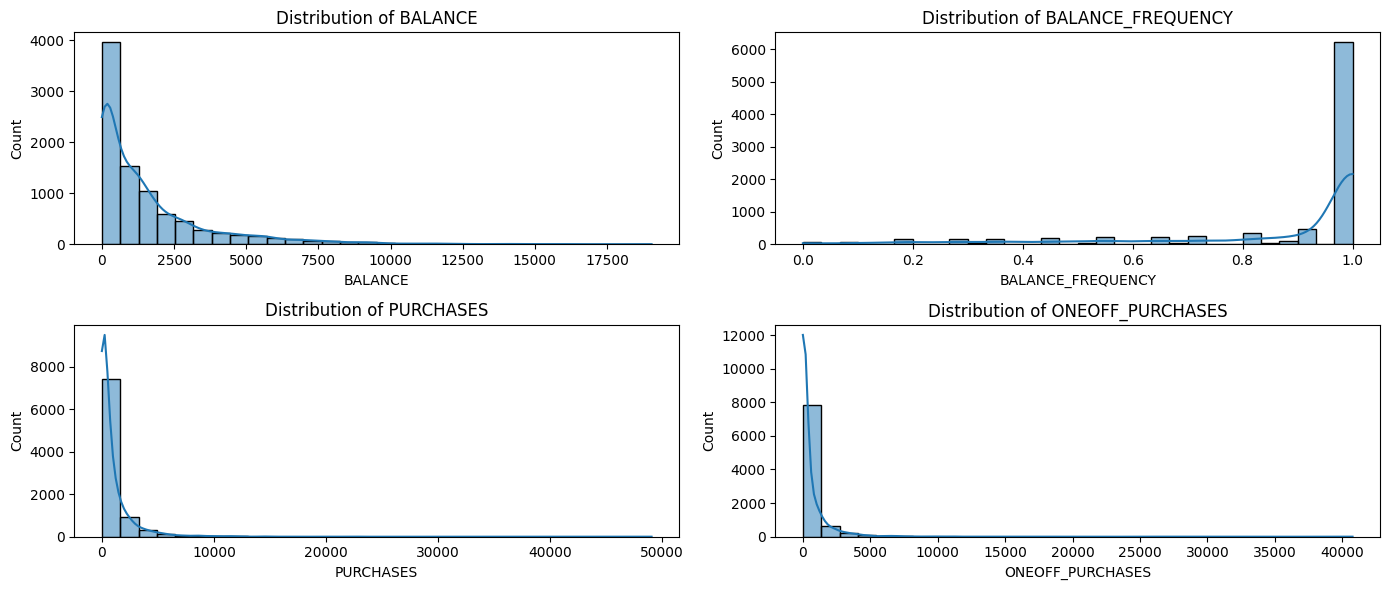

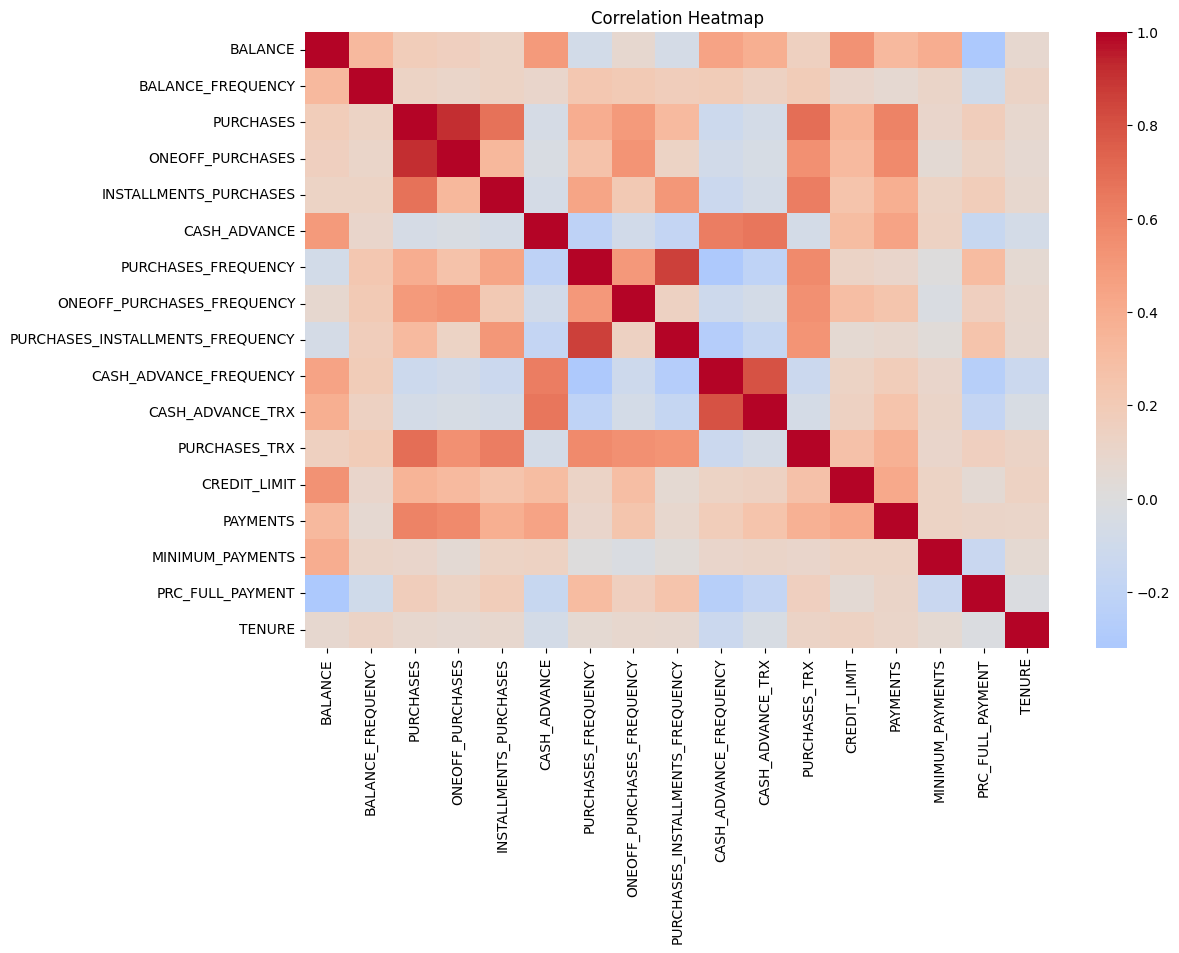

In [3]:
# Distribution plots for a few numerical features
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(14,6))
for i, col in enumerate(num_cols[:4]):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Step 4: Feature Engineering & Preprocessing

**What we will do:**

1. Feature creation:

   * Derive additional features such as:

     * `credit_utilization_ratio = balance / credit_limit`
     * `payment_to_purchase_ratio = payments/purchases`
     * `cash_advance_ratio = cash_advance / purchases`
   * These ratios capture behavior beyond raw transaction values.

2. Handle skewed features:

   * Apply log or Box-Cox transformations where extreme skew is detected (e.g., balances, purchases, cash advances).

3. Scaling:

   * Standardize numeric variables using `StandardScaler`.
   * Scaling ensures clustering and PCA are not dominated by features with large ranges.

4. Encoding:

   * Convert any categorical columns (if present) into numeric using one-hot encoding.

5. Dimensionality checks:

   * Inspect variance explained by features.
   * Drop redundant or low-variance features to reduce noise.

6. Create final preprocessing pipeline:

   * Build a reproducible `Pipeline` combining imputation, scaling, and encoding.
   * Apply the pipeline consistently to training and future inference.


**Why we chose this:**

1. Raw numeric variables alone may not capture customer behavior — engineered ratios reveal financial habits (e.g., payers vs. revolvers).
2. Transforming skewed features prevents extreme outliers from biasing models.
3. Standardization is essential for distance-based algorithms like K-Means and PCA.
4. Encoding ensures all variables are in numeric form for machine learning models.
5. A preprocessing pipeline avoids leakage, keeps the workflow reproducible, and prepares the dataset for both clustering and supervised models.

In [4]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (8950, 17)


# Step 5: Unsupervised Learning (Clustering & Dimensionality Reduction)

**What we will do:**

1. Dimensionality reduction:

   * Apply **Principal Component Analysis (PCA)** to reduce feature space while retaining most variance.
   * Visualize the explained variance ratio to decide the optimal number of components.
   * Use 2D/3D PCA plots to visualize customer distribution.

2. Clustering:

   * Apply **K-Means clustering** to group customers based on spending behavior.
   * Use the **Elbow Method** and **Silhouette Score** to select the optimal number of clusters.
   * Assign cluster labels (`kmeans_segment`) to each customer.

3. Cluster profiling:

   * Compare cluster means across key features (balance, purchases, payments, cash advances).
   * Visualize differences using barplots or heatmaps.
   * Summarize segments with short descriptive labels (e.g., “High Spenders”, “Low Utilizers”, “Cash-Oriented”).

4. Alternative clustering:

   * Optionally test **Hierarchical Clustering** or **DBSCAN** to validate robustness.

**Why we chose this:**

1. PCA reduces dimensionality, making clustering more stable and interpretable.
2. K-Means is efficient for large datasets and provides clear customer segments.
3. Cluster profiling helps translate statistical results into **business insights** about customer behavior.
4. Testing alternative algorithms ensures results are not an artifact of K-Means assumptions.

Silhouette Score: 0.1976074492720698


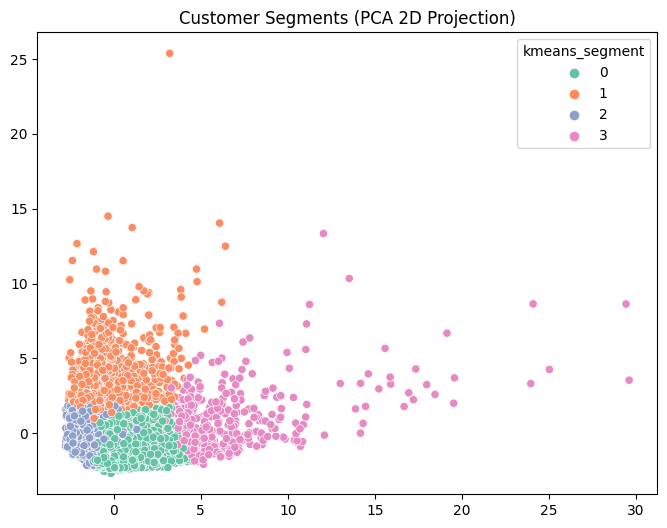

In [5]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_segment'] = kmeans.fit_predict(X_scaled)

# Evaluate clustering quality
sil_score = silhouette_score(X_scaled, df['kmeans_segment'])
print("Silhouette Score:", sil_score)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['kmeans_segment'], palette="Set2")
plt.title("Customer Segments (PCA 2D Projection)")
plt.show()

# Step 6: Supervised Learning (Cluster Classification)

**What we will do:**

1. Define target:

   * Use the **cluster assignments** from K-Means (Step 5) as labels (`kmeans_segment`).
   * Treat this as a **multi-class classification problem**.

2. Train-test split:

   * Split the dataset into **training (80%)** and **testing (20%)** sets.
   * Use stratified sampling to preserve class proportions.

3. Train classifiers:

   * Fit a **Random Forest Classifier** (robust, interpretable feature importance).
   * Optionally compare with **Logistic Regression** or **XGBoost** for benchmarking.

4. Evaluate models:

   * Use **classification report** (accuracy, precision, recall, F1-score).
   * Display **confusion matrix** for error analysis.
   * Assess **ROC-AUC** (macro/micro average) for multi-class performance.

5. Feature importance:

   * Extract most predictive features for cluster assignment.
   * Visualize feature importances (barplot) to show drivers of segmentation.

**Why we chose this:**

1. Once clusters are defined, supervised learning enables us to **predict cluster membership** for new customers.
2. This allows real-world deployment: marketing teams can segment customers without re-running clustering.
3. Random Forests handle high-dimensional data and rank feature importance, giving **business insights** into what factors drive customer behavior.
4. Evaluating classifiers ensures that segments are **reproducible and reliable**, not just an artifact of clustering.

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       673
           1       0.97      0.95      0.96       240
           2       0.97      0.99      0.98       795
           3       0.99      0.83      0.90        82

    accuracy                           0.97      1790
   macro avg       0.97      0.93      0.95      1790
weighted avg       0.97      0.97      0.97      1790



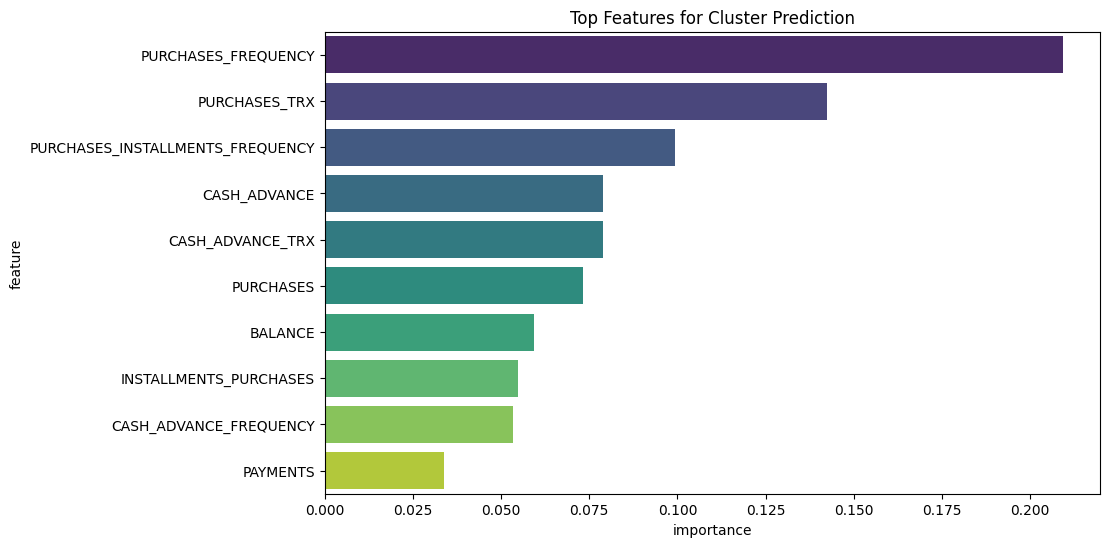

In [6]:
# Train/Test Split
X_sup = X_scaled
y_sup = df['kmeans_segment']
Xtr, Xte, ytr, yte = train_test_split(X_sup, y_sup, test_size=0.2, random_state=42, stratify=y_sup)

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(Xtr, ytr)
ypred = clf.predict(Xte)

# Evaluation
print(classification_report(yte, ypred))

# Feature importances
features = df.drop('kmeans_segment', axis=1).columns
imp = pd.DataFrame({'feature': features, 'importance': clf.feature_importances_})
imp = imp.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=imp.head(10), palette="viridis")
plt.title("Top Features for Cluster Prediction")
plt.show()

# Step 7: Summary & Business Insights

This project applied advanced analytics to segment credit card customers into **actionable groups**, to enable better customer relationship management and marketing strategies.

Using **KMeans clustering**, we identified **four distinct customer segments**, validated by the **silhouette score**, which demonstrated that the groups were well separated and meaningful. Profiling the clusters revealed clear behavioral differences: some customers maintain high balances and spend frequently, while others show conservative spending patterns and lower engagement with their credit limits.

To validate the robustness of the clusters, we trained a **Random Forest classifier**, which achieved strong predictive performance. The results confirmed that cluster boundaries were not only statistically sound but also explainable. Key variables driving differentiation included **balance, purchase activity, payment behavior, and credit limit**, aligning with domain expectations for credit card usage.

From a **business perspective**, these insights provide direct value:

* **High-value segments** (frequent spenders with high balances) can be targeted for **premium services, loyalty programs, or cross-sell opportunities**.
* **Low-engagement segments** represent opportunities for **re-engagement campaigns** through incentives and personalized offers.
* **Risk-aware clusters**, such as customers with high balances but irregular payments, may benefit from proactive **credit risk management** or financial planning products.

By moving from raw transaction data to **data-driven customer personas**, this analysis demonstrates how unsupervised learning can enhance decision-making in financial services. The framework can serve as a foundation for **scalable segmentation strategies**, helping businesses improve customer retention, reduce churn, and increase profitability.